# Import and setup

In [1]:
from pynamicalsys import HamiltonianSystem as HS
from pynamicalsys import PlotStyler

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
HS.available_models()

['henon heiles']

In [4]:
path_figures = "../images"

# Quickstart

In [5]:
hs = HS(model="henon heiles")

In [6]:
num_ic = 100
dof = 2
q = np.zeros((num_ic, dof))
p = np.zeros((num_ic, dof))
E_ref = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y_range = (-0.5, 0.5)
py_range = (-0.5, 0.5)

np.random.seed(13)
for i in range(num_ic):
    while True:
        py = np.random.uniform(*py_range)
        y = np.random.uniform(*y_range)
        px = 2 * (E_ref - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2
        if px > 0:
            q[i] = [x, y]
            p[i] = [np.sqrt(px), py]
            break
num_intersections = 10000
time_step = 0.01

In [7]:
hs.integrator("vv2", time_step=time_step)

In [8]:
q0 = q.copy()
p0 = p.copy()
PS_vv2 = hs.poincare_section(q0, p0, num_intersections)

In [9]:
hs.integrator("svy4", time_step=time_step)

In [10]:
q0 = q.copy()
p0 = p.copy()
PS_svy4 = hs.poincare_section(q0, p0, num_intersections)

<Figure size 640x480 with 0 Axes>

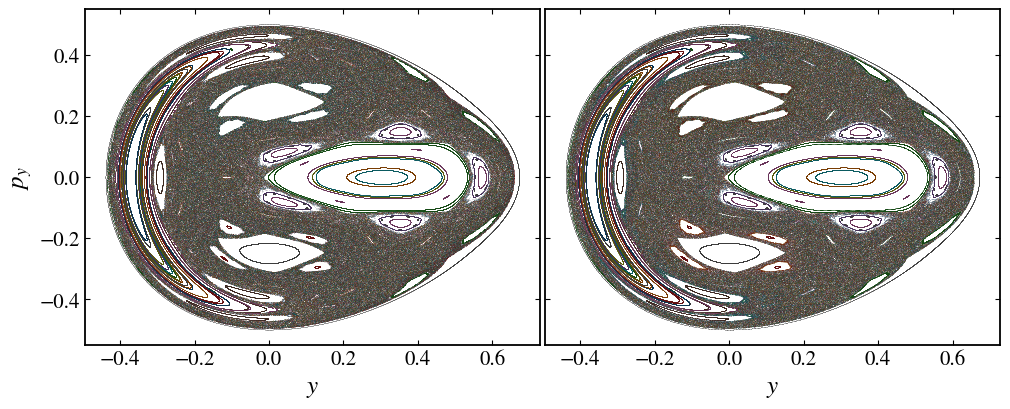

In [13]:
ps = PlotStyler(fontsize=18, markersize=0.25, markeredgewidth=0)
ps.apply_style()

colors = sns.color_palette("tab10", num_ic)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 4))

for i in range(num_ic):
    ax[0].plot(PS_vv2[i, :, 2], PS_vv2[i, :, 4], "o", c=colors[i])
    ax[1].plot(PS_svy4[i, :, 2], PS_svy4[i, :, 4], "o", c=colors[i])

ax[0].set_xlabel("$y$")
ax[1].set_xlabel("$y$")
ax[0].set_ylabel("$p_y$")

plt.tight_layout(pad=0.2)
plt.savefig(f"{path_figures}/henon_heiles_poincare_section.png", dpi=400)